### Nature of data of Diabetes


1. Pregnancies

    Type: Numerical (Integer)
    
    Nature: Discrete
    
    Meaning: Number of times the patient has been pregnant.

2. Glucose

    Type: Numerical (Integer)
    
    Nature: Continuous

    Meaning: Plasma glucose concentration after 2 hours in an oral glucose tolerance test.

3. BloodPressure

    Type: Numerical (Integer)
    
    Nature: Continuous
    
    Meaning: Diastolic blood pressure (mm Hg).

4. SkinThickness

    Type: Numerical (Integer)
    
    Nature: Continuous
    
    Meaning: Triceps skinfold thickness (mm).

5. Insulin

    Type: Numerical (Integer)
    
    Nature: Continuous
    
    Meaning: 2-hour serum insulin level (mu U/ml).

6. BMI

    Type: Numerical (Float)
    
    Nature: Continuous
    
    Meaning: Body Mass Index = weight (kg) / height² (m²).

7. DiabetesPedigreeFunction

    Type: Numerical (Float)
    
    Nature: Continuous
    
    Meaning: Likelihood of diabetes based on family history.

8. Age

    Type: Numerical (Integer)
    
    Nature: Discrete (but often treated as continuous)
    
    Meaning: Age of the patient in years.

9. Outcome

    Type: Categorical (0/1)
    
    Nature: Binary Classification Target
    
    Meaning:
    
    0 = No diabetes
    
    1 = Diabetes

| Column                   | Type              | Nature     | Description                   |
| ------------------------ | ----------------- | ---------- | ----------------------------- |
| Pregnancies              | Numeric (int)     | Discrete   | Number of pregnancies         |
| Glucose                  | Numeric (int)     | Continuous | Plasma glucose level          |
| BloodPressure            | Numeric (int)     | Continuous | Diastolic blood pressure      |
| SkinThickness            | Numeric (int)     | Continuous | Triceps skinfold thickness    |
| Insulin                  | Numeric (int)     | Continuous | Serum insulin                 |
| BMI                      | Numeric (float)   | Continuous | Body Mass Index               |
| DiabetesPedigreeFunction | Numeric (float)   | Continuous | Diabetes family history score |
| Age                      | Numeric (int)     | Discrete   | Age in years                  |
| Outcome                  | Categorical (0/1) | Binary     | Diabetes status               |


Importing the Dependencies

In [1]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:

# loading the diabetes dataset to a pandas DataFrame

diabetes_dataset = pd.read_csv('diabetes.csv') 


In [3]:

# printing the first 5 rows of the dataset

diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:

# number of rows and Columns in this dataset

diabetes_dataset.shape


(768, 9)

In [ ]:

# getting the statistical measures of the data

diabetes_dataset.describe()

In [5]:
diabetes_dataset['Outcome'].unique()

array([1, 0], dtype=int64)

In [6]:

diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

0 --> Non-Diabetic

1 --> Diabetic

In [12]:

diabetes_dataset.groupby('Outcome').size().reset_index()

,Outcome,0
0,0,500
1,1,268


In [13]:

# separating the data and labels

X = diabetes_dataset.drop(columns = 'Outcome', axis=1)

Y = diabetes_dataset['Outcome']


In [14]:

print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [15]:

print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [ ]:

#Train Test Split

In [16]:

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)

In [17]:

print(X.shape, X_train.shape, X_test.shape)


(768, 8) (614, 8) (154, 8)


Training the Model

In [19]:

from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier()

In [20]:

#training the support vector Machine Classifier

classifier.fit(X_train, Y_train)

DecisionTreeClassifier()

In [22]:
# Model Testing

X_train_prediction = classifier.predict(X_train)


Accuracy Score

In [25]:
# accuracy score on the training data

training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [26]:

print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  1.0


In [27]:

# accuracy score on the test data

X_test_prediction = classifier.predict(X_test)

test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [28]:

print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.7012987012987013


# Making a Predictive System

In [29]:

input_data = (5,166,72,19,175,25.8,0.587,51)

input_data_df = pd.DataFrame([input_data], columns=X.columns)

prediction = classifier.predict(input_data_df)

if prediction[0] == 0:
    print('The person is not diabetic')
else:
    print('The person is diabetic')
    

The person is diabetic


# Comparitive study

In [30]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

models = []
models.append(('KNN', KNeighborsClassifier()))
models.append(('DT', DecisionTreeClassifier()))

models

[('KNN', KNeighborsClassifier()), ('DT', DecisionTreeClassifier())]

In [31]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify = diabetes_dataset.Outcome, random_state=0)

names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred)*100)
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)


  Name      Score
0  KNN  75.520833
1   DT  76.562500


# Ver 2

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

# Assuming diabetes_dataset is already loaded
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

models = [
    ('KNN', KNeighborsClassifier()),
  
    ('DT', DecisionTreeClassifier())
]

X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, random_state=0)

# Lists for scores
names, accuracies, precisions, recalls, f1s = [], [], [], [], []

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Store metrics
    names.append(name)
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average='binary'))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    
    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))



--- KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       125
           1       0.66      0.61      0.64        67

    accuracy                           0.76       192
   macro avg       0.73      0.72      0.73       192
weighted avg       0.75      0.76      0.75       192

--- DT Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       125
           1       0.68      0.66      0.67        67

    accuracy                           0.77       192
   macro avg       0.75      0.74      0.75       192
weighted avg       0.77      0.77      0.77       192



In [33]:
# Create summary DataFrame

metrics_df = pd.DataFrame({
    'Model': names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1s
})

print("\nModel Evaluation Summary:")
print(metrics_df)



Model Evaluation Summary:
  Model  Accuracy  Precision    Recall  F1 Score
0   KNN  0.755208   0.661290  0.611940  0.635659
1    DT  0.770833   0.676923  0.656716  0.666667


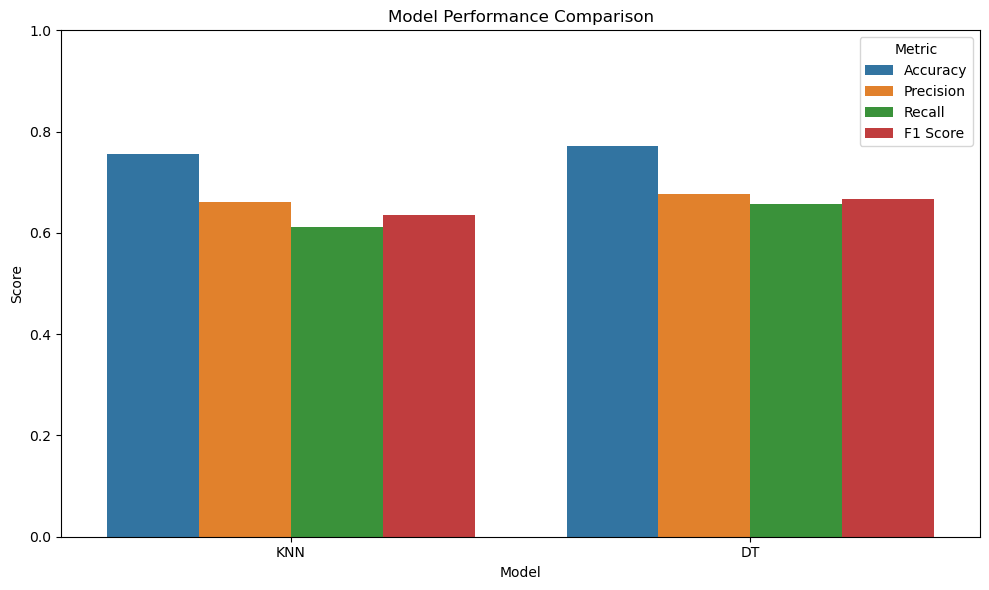

In [34]:
# Plotting
plt.figure(figsize=(10,6))
sns.barplot(data=metrics_df.melt(id_vars='Model'), x='Model', y='value', hue='variable')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


In [37]:
metrics_df_sorted = metrics_df.sort_values(by='Accuracy')
metrics_df_sorted

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.755208,0.661290,0.611940,0.635659
1,DT,0.770833,0.676923,0.656716,0.666667


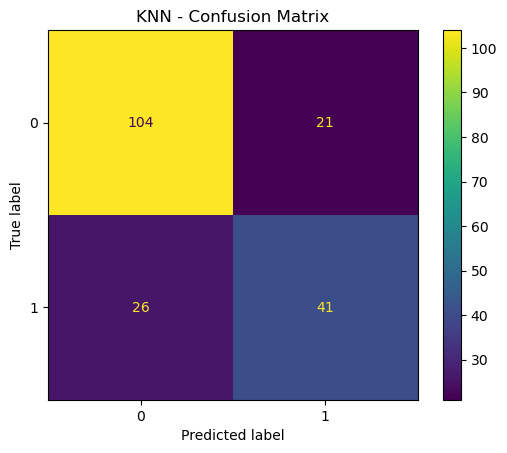

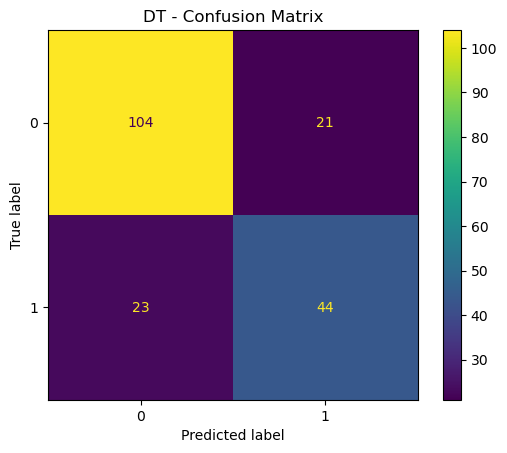

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models:
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [38]:
metrics_df.melt(id_vars='Model')

,Model,variable,value
0,KNN,Accuracy,0.755208
1,DT,Accuracy,0.770833
2,KNN,Precision,0.661290
3,DT,Precision,0.676923
4,KNN,Recall,0.611940
5,DT,Recall,0.656716
6,KNN,F1 Score,0.635659
7,DT,F1 Score,0.666667


<Axes: xlabel='Model', ylabel='value'>

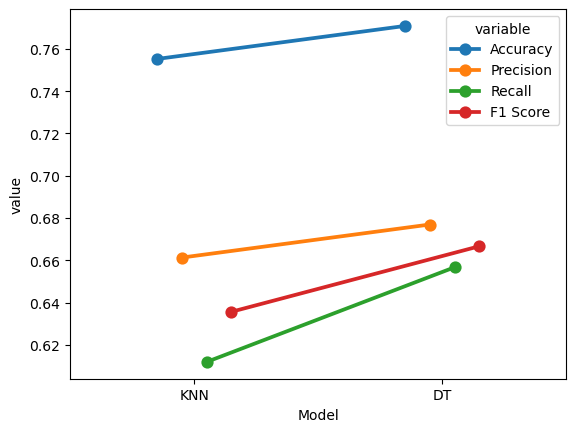

In [39]:
sns.pointplot(
    data=metrics_df.melt(id_vars='Model'),
    x='Model',
    y='value',
    hue='variable',
    markers='o',
    linestyles='-',  
    dodge=0.3
)

Decision Tree clearly outperforms KNN on all evaluation metrics.

DT is better at classifying both positive and negative classes.

KNN performs reasonably but struggles slightly with recall and F1 score, showing it may not capture complex decision boundaries as well.